In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported

from statsforecast import StatsForecast
from statsforecast.models import ARIMA

from pathlib import Path
import sys

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
    
TARGET_COL = "sell_bid"  # change to "sell_bid" for sell-side experiment
LAG_SUFFIX = "pb" if TARGET_COL == "purchase_bid" else "sb"
HORIZON = 96 * 7
PARAMS_PATH = Path("data/processed/params/ts_params.json")

from forecasting.data.loaders import load_market_data
from forecasting.features.market import add_daily_clf, add_nci, add_rolling_3d_clf
from forecasting.utils.io import save_json, load_json

from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA, ARIMA, AutoTBATS
from statsforecast.arima import arima_string

In [3]:
indexed_data = load_market_data("../../../data/raw/iex-dam-0201-0421.csv")
data = indexed_data.reset_index()
data.sample()

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
6570,2026-04-10 10:30:00,10:30 - 10:45,9071.6,55998.9,8844.2,649.56,8844.2


In [7]:
data = data.rename(columns={
    'period_start': 'ds',  # Your timestamp
    TARGET_COL: 'y'             # The target value you want to plot (Market Clearing Price)
})
filtered_data = data[[ "ds", "y" ]].copy()
filtered_data['unique_id'] = 'series_1'
filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])

test = filtered_data.groupby("unique_id").tail(horizon)
train = filtered_data.drop(test.index).reset_index(drop=True)

### SARIMA

In [9]:
horizon = 96*7
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96)")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
preds = sf.predict(h=horizon)

model_col = "SARIMA (0,1,0,0,1,1,96)"

# Force all values below 0 to be exactly 0
preds[model_col] = preds[model_col].clip(lower=0)

test_w_preds = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [11]:
metrics = evaluate(
    test_w_preds,
    metrics=[mae],
)
metrics

,unique_id,metric,"SARIMA (0,1,0,0,1,1,96)"
0,series_1,mae,4848.497937


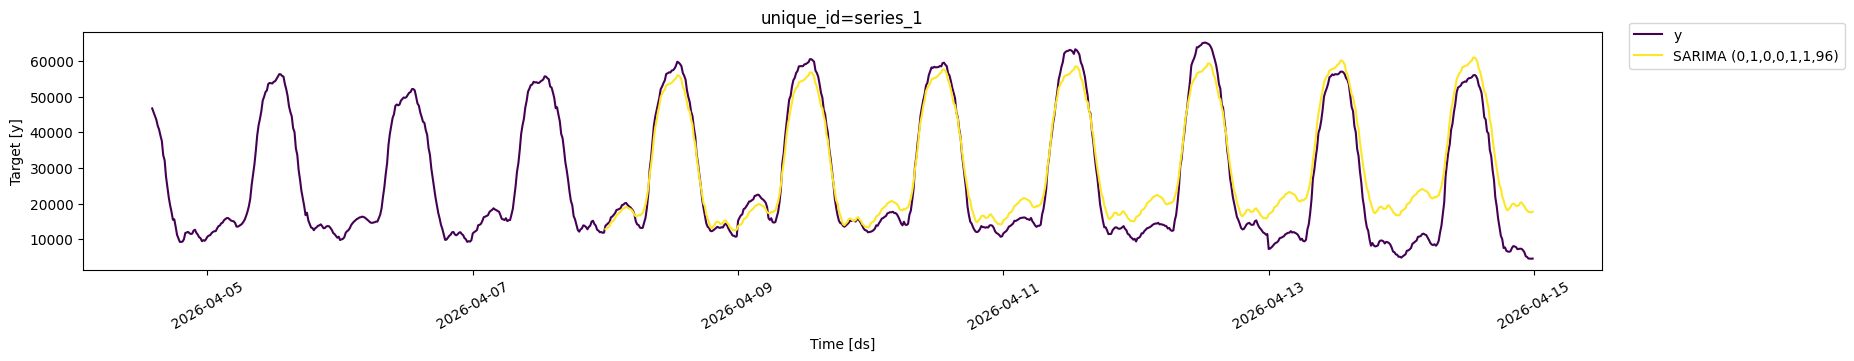

In [12]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

In [18]:
start_mmdd = preds['ds'].min().strftime('%m%d')
end_mmdd = preds['ds'].max().strftime('%m%d')

to_save = test_w_preds.rename(columns={"SARIMA (0,1,0,0,1,1,96)": "pred", "ds": "timestamp"}).drop(columns=["unique_id", "y"])

# 3. Construct the filename
filename = f"../../../data/predictions/{LAG_SUFFIX}_timeseries_{start_mmdd}_{end_mmdd}.csv"

# 4. Save to CSV
to_save.to_csv(filename)

print(f"File saved successfully as: {filename}")

File saved successfully as: ../../../data/predictions/sb_timeseries_0408_0414.csv


In [15]:
to_save

,timestamp,pred
0,2026-04-08 00:00:00,12837.928449
1,2026-04-08 00:15:00,13119.784541
2,2026-04-08 00:30:00,13338.896054
3,2026-04-08 00:45:00,13730.420279
4,2026-04-08 01:00:00,14760.873621
...,...,...
667,2026-04-14 22:45:00,18138.999295
668,2026-04-14 23:00:00,17628.984130
669,2026-04-14 23:15:00,17681.107452
670,2026-04-14 23:30:00,17491.569840
